# Industrial Knowledge Graph - Mining Operations

Real-world knowledge graph for mining operations showing equipment dependencies, failure analysis, and operational insights.

In [1]:
import networkx as nx
import pandas as pd
from datetime import datetime, timedelta

# Create industrial knowledge graph
G = nx.DiGraph()

# Mining operation triples (entity, relation, entity)
triples = [
    # Site hierarchy
    ("Copper_Mine_Alpha", "contains", "Processing_Plant_1"),
    ("Processing_Plant_1", "contains", "Crushing_Circuit"),
    ("Processing_Plant_1", "contains", "Grinding_Circuit"),
    ("Processing_Plant_1", "contains", "Flotation_Circuit"),
    
    # Equipment in circuits
    ("Crushing_Circuit", "contains", "Crusher_CR001"),
    ("Crushing_Circuit", "contains", "Conveyor_CV001"),
    ("Grinding_Circuit", "contains", "Ball_Mill_BM001"),
    ("Grinding_Circuit", "contains", "Cyclone_CY001"),
    ("Flotation_Circuit", "contains", "Flotation_Cell_FC001"),
    
    # Process flow dependencies
    ("Crusher_CR001", "feeds_to", "Conveyor_CV001"),
    ("Conveyor_CV001", "feeds_to", "Ball_Mill_BM001"),
    ("Ball_Mill_BM001", "feeds_to", "Cyclone_CY001"),
    ("Cyclone_CY001", "feeds_to", "Flotation_Cell_FC001"),
    
    # Equipment failures and impacts
    ("Ball_Mill_BM001", "has_failure", "Bearing_Failure_BF001"),
    ("Bearing_Failure_BF001", "occurred_on", "2024-01-15"),
    ("Bearing_Failure_BF001", "caused_by", "Inadequate_Lubrication"),
    ("Bearing_Failure_BF001", "impacts", "Production_Loss_PL001"),
    ("Production_Loss_PL001", "cost_usd", "250000"),
    
    # Maintenance and personnel
    ("Bearing_Failure_BF001", "repaired_by", "Maintenance_Team_MT001"),
    ("Maintenance_Team_MT001", "specializes_in", "Mechanical_Systems"),
    ("Maintenance_Team_MT001", "uses_part", "Bearing_SKF_23144"),
    ("Bearing_SKF_23144", "supplier", "SKF_Industrial"),
    ("Bearing_SKF_23144", "lead_time_days", "14"),
    
    # Performance metrics
    ("Ball_Mill_BM001", "throughput_tph", "450"),
    ("Ball_Mill_BM001", "availability_percent", "87"),
    ("Flotation_Cell_FC001", "recovery_percent", "92"),
    
    # Sensor data and monitoring
    ("Ball_Mill_BM001", "monitored_by", "Vibration_Sensor_VS001"),
    ("Vibration_Sensor_VS001", "alert_threshold", "15_mm_s"),
    ("Vibration_Sensor_VS001", "current_reading", "18_mm_s"),
    ("Vibration_Sensor_VS001", "status", "ALARM")
]

# Build the graph
for h, r, t in triples:
    G.add_edge(h, t, relation=r)

print(f"Industrial KG created with {len(G.nodes())} entities and {len(G.edges())} relationships")

Industrial KG created with 27 entities and 30 relationships


In [2]:
def get_tail_relations(entity):
    """Relations where entity is the head (outgoing)."""
    return [G[entity][t]['relation'] for t in G.successors(entity)]

def get_head_relations(entity):
    """Relations where entity is the tail (incoming)."""
    return [G[h][entity]['relation'] for h in G.predecessors(entity)]

def get_tail_entities(entity, relation):
    """All tails connected by a given relation."""
    return [t for t in G.successors(entity) if G[entity][t]['relation'] == relation]

def get_head_entities(entity, relation):
    """All heads connected by a given relation."""
    return [h for h in G.predecessors(entity) if G[h][entity]['relation'] == relation]

In [3]:
# Business question: Why did we lose $250k in production last month?
question = "What caused the $250k production loss and how can we prevent it?"

print(f"Business Question: {question}")
print("=" * 60)

# Step 1: Find what caused the production loss
loss_causes = get_head_entities("Production_Loss_PL001", "impacts")
print(f"Production loss caused by: {loss_causes}")

# Step 2: What equipment had this failure?
failed_equipment = get_head_entities(loss_causes[0], "has_failure")
print(f"Failed equipment: {failed_equipment}")

# Step 3: What was the root cause?
root_cause = get_tail_entities(loss_causes[0], "caused_by")
print(f"Root cause: {root_cause}")

# Step 4: What circuit is this equipment in?
circuit = get_head_entities(failed_equipment[0], "contains")
print(f"Equipment location: {circuit}")

# Step 5: What's the downstream impact?
downstream = get_tail_entities(failed_equipment[0], "feeds_to")
print(f"Downstream equipment affected: {downstream}")

print("\n" + "=" * 60)
print("BUSINESS INSIGHT:")
print(f"The ${get_tail_entities('Production_Loss_PL001', 'cost_usd')[0]} loss was caused by")
print(f"bearing failure in {failed_equipment[0]} due to {root_cause[0]}.")
print(f"Current vibration levels are above threshold, indicating ongoing risk.")

Business Question: What caused the $250k production loss and how can we prevent it?
Production loss caused by: ['Bearing_Failure_BF001']
Failed equipment: ['Ball_Mill_BM001']
Root cause: ['Inadequate_Lubrication']
Equipment location: ['Grinding_Circuit']
Downstream equipment affected: ['Cyclone_CY001']

BUSINESS INSIGHT:
The $250000 loss was caused by
bearing failure in Ball_Mill_BM001 due to Inadequate_Lubrication.
Current vibration levels are above threshold, indicating ongoing risk.


C:\Users\zeinab.shahraki\AppData\Local\Temp\ipykernel_9404\3924852525.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


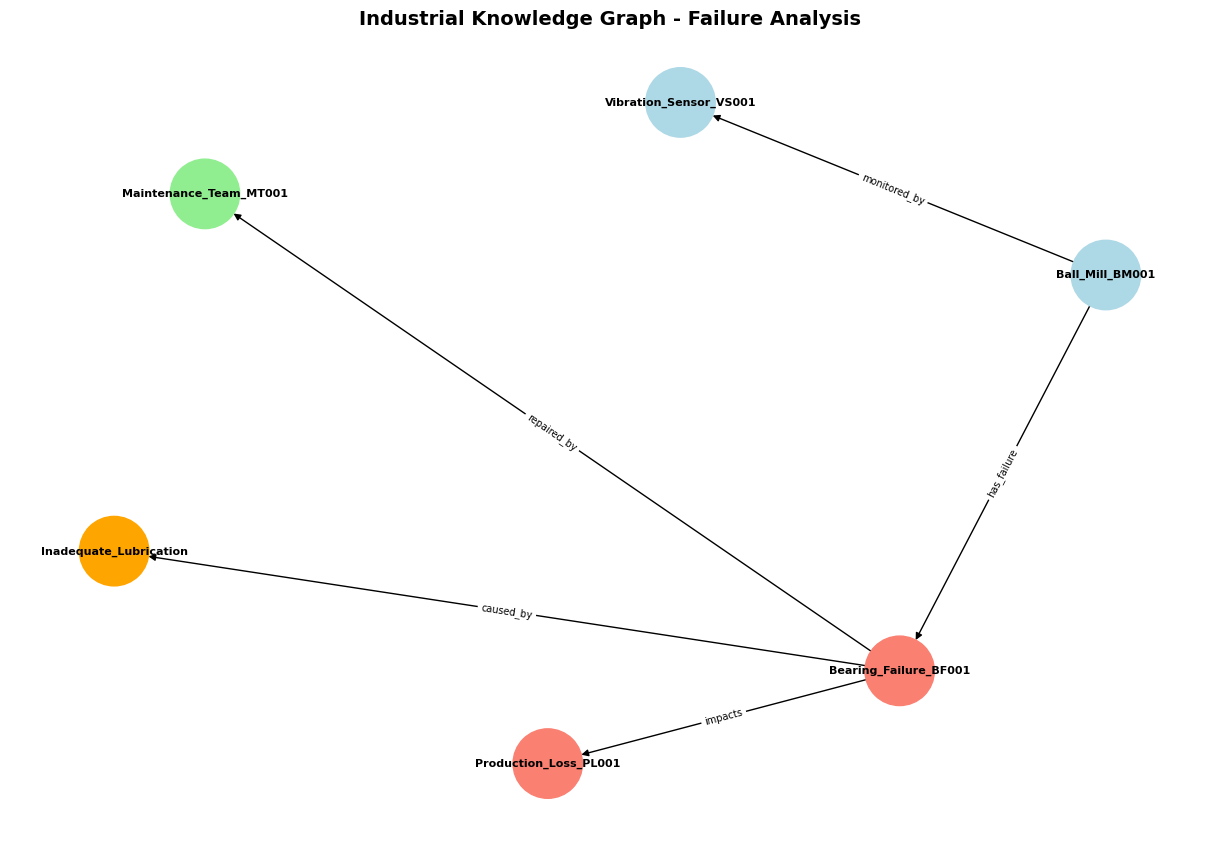

In [4]:
import matplotlib.pyplot as plt

# Create subgraph for key equipment and failures
key_nodes = ["Ball_Mill_BM001", "Bearing_Failure_BF001", "Production_Loss_PL001", 
             "Inadequate_Lubrication", "Maintenance_Team_MT001", "Vibration_Sensor_VS001"]

subgraph = G.subgraph(key_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph, k=3, iterations=50)

# Color nodes by type
node_colors = []
for node in subgraph.nodes():
    if "Mill" in node or "Sensor" in node:
        node_colors.append("lightblue")  # Equipment
    elif "Failure" in node or "Loss" in node:
        node_colors.append("salmon")      # Problems
    elif "Team" in node:
        node_colors.append("lightgreen")  # People
    else:
        node_colors.append("orange")      # Causes

nx.draw(subgraph, pos, with_labels=True, node_color=node_colors, 
         node_size=2500, font_size=8, font_weight="bold")

# Add edge labels
edge_labels = nx.get_edge_attributes(subgraph, 'relation')
nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_size=7)

plt.title("Industrial Knowledge Graph - Failure Analysis", size=14, weight="bold")
plt.tight_layout()
plt.show()